# Cardiovascular Disease Prediction
---

**Author:** Ahmad Saeed  
**Date:** 31-03-2025  
**Dataset:** Cardiovascular Disease Dataset (Kaggle)  
**Notebook:** 01 — Exploratory Data Analysis

---

## Objective

The goal of this notebook is to perform a thorough **Exploratory Data Analysis (EDA)** on the Cardiovascular Disease dataset before building any predictive model.

By the end of this notebook, we will:
- Understand the structure and quality of the dataset
- Identify missing values and outliers
- Analyze the distribution of features
- Discover relationships between features and the target variable (`cardio`)
- Extract key insights to guide feature engineering and modeling

## Table of Contents

1. [Import Libraries](#1)
2. [Load Dataset](#2)
3. [Dataset overview](#3)
4. [Missing values and Duplicates](#4)
5. [Target Variable Analysis](#5)
6. [Numerical Features Analysis](#6)
7. [Categorical Features Analysis](#7)
8. [Correlation Analysis](#9)
9. [Key Insights & Next Steps](#10)

---
## 1. Import Libraries <a id='1'></a>

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)                 # Show all columns
pd.set_option('display.float_format', '{:.2f}'.format)     # Format float values
sns.set_theme(style='darkgrid')                            # default plot style
plt.rcParams['figure.figsize'] = (10, 5)                   # figure size
plt.rcParams['figure.dpi'] = 100                           # figure resolution

print("Libraries imported successfully")

Libraries imported successfully


---
## 2. Load the dataset <a id="2"></a>

In [2]:
df = pd.read_csv("cardio_train.csv",sep=';')
df.head() # Display the first few rows of the dataset

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.00,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.00,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.00,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.00,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.00,100,60,1,1,0,0,0,0


---
## 3. Dataset overview <a id="3"></a>

In [3]:
df.info() # Get a concise summary of the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [4]:
df.describe() # Get summary statistics of the dataset

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.80,0.50
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.40,0.50
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.00,0.00
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.00,0.00
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.00,1.00
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.00,1.00


### Obeservations

| # | Property | Finding | Action |
|:---|:---|:---|:---|
| 1 | **Shape** | 70,000 rows × 13 columns | — |
| 2 | **Data Types** | All `int64` except `weight` (`float64`) | Cast categoricals to `category` |
| 3 | **Categorical Columns** | `gender`, `cholesterol`, `gluc`, `smoke`, `alco`, `active` | Cast to `category` dtype |
| 4 | **Age Column** | Stored in days (max: 23,713) | Convert → `age / 365` |
| 5 | **ID Column** | No predictive value | Drop before modeling |
| 6 | **Outliers** | `ap_hi` max 16,020 mmHg, `ap_lo` has negative values | Remove impossible values |
| 7 | **Class Balance** | 50.0% / 50.0% | No resampling needed |

---
## 4. Missing values and duplicates <a id="4"></a>

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else " No missing values found!")

# Duplicates
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

Missing values per column:
 No missing values found!

Duplicate rows: 0


---
## 5. Target Variable Analysis <a id="5"></a>

Class Distribution:
  No Disease (0) : 35,021  (50.0%)
  Disease    (1) : 34,979  (50.0%)


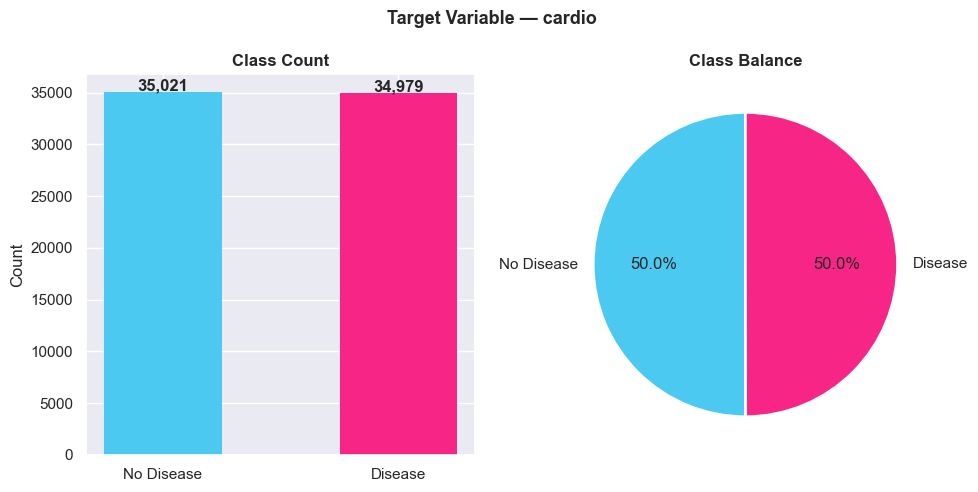

In [6]:
# ------- Target Variable Analysis -------

# Compute class counts (0 = No Disease, 1 = Disease)
target_counts = df['cardio'].value_counts().sort_index()

# Compute percentage distribution for class balance insight
target_pct = df['cardio'].value_counts(normalize=True).sort_index() * 100

# Quick summary printout for sanity check
print("Class Distribution:")
print(f"  No Disease (0) : {target_counts[0]:>6,}  ({target_pct[0]:.1f}%)")
print(f"  Disease    (1) : {target_counts[1]:>6,}  ({target_pct[1]:.1f}%)")


# ------- Visualization -------

# Create side-by-side plots (count + proportion view)
fig, axes = plt.subplots(1, 2)

# --- Bar Chart: Absolute class counts ---
axes[0].bar(
    ['No Disease', 'Disease'],
    target_counts.values,
    color=['#4cc9f0', '#f72585'],
    width=0.5,
    edgecolor='none'
)

# Annotate bars with exact counts
for bar, val in zip(axes[0].patches, target_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,}',
        ha='center',
        fontweight='bold'
    )

axes[0].set_title('Class Count', fontweight='bold')
axes[0].set_ylabel('Count')


# --- Pie Chart: Relative class distribution ---
axes[1].pie(
    target_counts.values,
    labels=['No Disease', 'Disease'],
    colors=['#4cc9f0', '#f72585'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

axes[1].set_title('Class Balance', fontweight='bold')


# Final layout adjustments
plt.suptitle('Target Variable — cardio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Numerical Feature Analysis <a id="6"></a>

In [7]:
## Add new columns for age in years and BMI for better interpretability and analysis

# Convert age from days to years (rounded to nearest integer)
df['age_years'] = (df['age'] / 365).round(0).astype(int)

# Calculate BMI from height and weight
df['bmi'] = (df['weight'] / ((df['height'] / 100) ** 2)).round(1)

# Display the first few rows to verify the new columns
df[['age', 'age_years', 'bmi']].head()

,age,age_years,bmi
0,18393,50,22.00
1,20228,55,34.90
2,18857,52,23.50
3,17623,48,28.70
4,17474,48,23.00


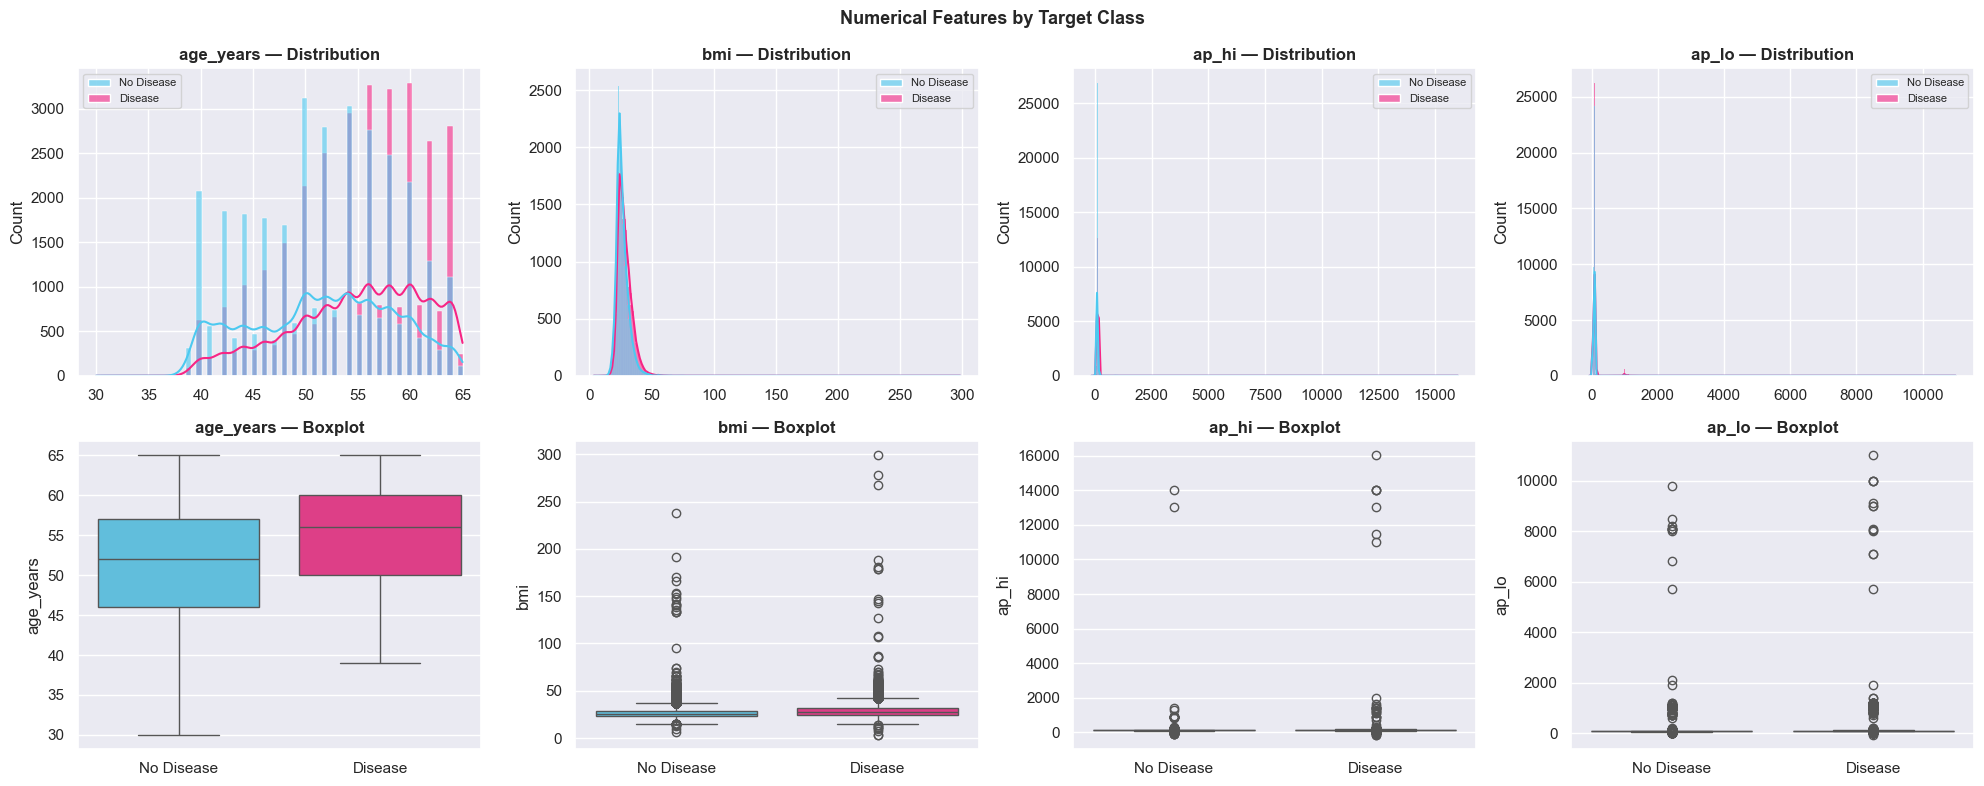

In [8]:
# ------- Numerical Features Analysis -------

# Numerical features selected for analysis
num_features = ['age_years', 'bmi', 'ap_hi', 'ap_lo']

# Create a 2x4 grid for distribution and boxplot views
fig, axes = plt.subplots(2, 4, figsize=(20, 8))


# ------- Row 1 : Distribution -------

# Plot feature distributions with class-wise separation
for i, feat in enumerate(num_features):
    sns.histplot(
        data=df,
        x=feat,
        hue='cardio',               # split by target class
        hue_order=[0, 1],
        palette={0: '#4cc9f0', 1: '#f72585'},
        kde=True,                   # add density curve
        alpha=0.6,
        ax=axes[0][i]
    )

    axes[0][i].set_title(f'{feat} — Distribution', fontweight='bold')
    axes[0][i].set_xlabel('')

    # Improve legend readability
    axes[0][i].legend(
        handles=axes[0][i].legend_.legend_handles,
        labels=['No Disease', 'Disease'],
        fontsize=8
    )


# ------- Row 2 : Boxplots -------

# Visualize spread and outliers across classes
for i, feat in enumerate(num_features):
    sns.boxplot(
        data=df,
        x='cardio',
        y=feat,
        hue='cardio',               # color by class
        palette={0: '#4cc9f0', 1: '#f72585'},
        legend=False,
        ax=axes[1][i]
    )

    axes[1][i].set_title(f'{feat} — Boxplot', fontweight='bold')
    axes[1][i].set_xlabel('')

    # Replace numeric labels with readable class names
    axes[1][i].set_xticks([0, 1])
    axes[1][i].set_xticklabels(['No Disease', 'Disease'])


# Final layout adjustments
plt.suptitle('Numerical Features by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Summary

| Feature | Observation | Outliers | Action |
|:---|:---|:---|:---|
| `age_years` | Disease group is clearly older — good class separation visible in both histogram and boxplot | None | No cleaning needed |
| `bmi` | Both classes heavily overlap — slight higher BMI in disease group | Values up to 300 present | Remove BMI > 60 |
| `ap_hi` | Real distribution invisible — outliers dominating the entire plot | Values up to 16,000 mmHg | Keep 60–250 mmHg only |
| `ap_lo` | Same issue as `ap_hi` — actual data crushed to left corner | Values up to 10,000 mmHg | Keep 40–200 mmHg only |

### Temporary Cleaning (Visualization Only)

In [9]:
# Temporary clean dataset for visualization and analysis (removing extreme outliers based on domain knowledge)
df_clean = df[
    (df['ap_hi'] >= 60)  & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40)  & (df['ap_lo'] <= 200) &
    (df['bmi']   <= 60)
].copy()

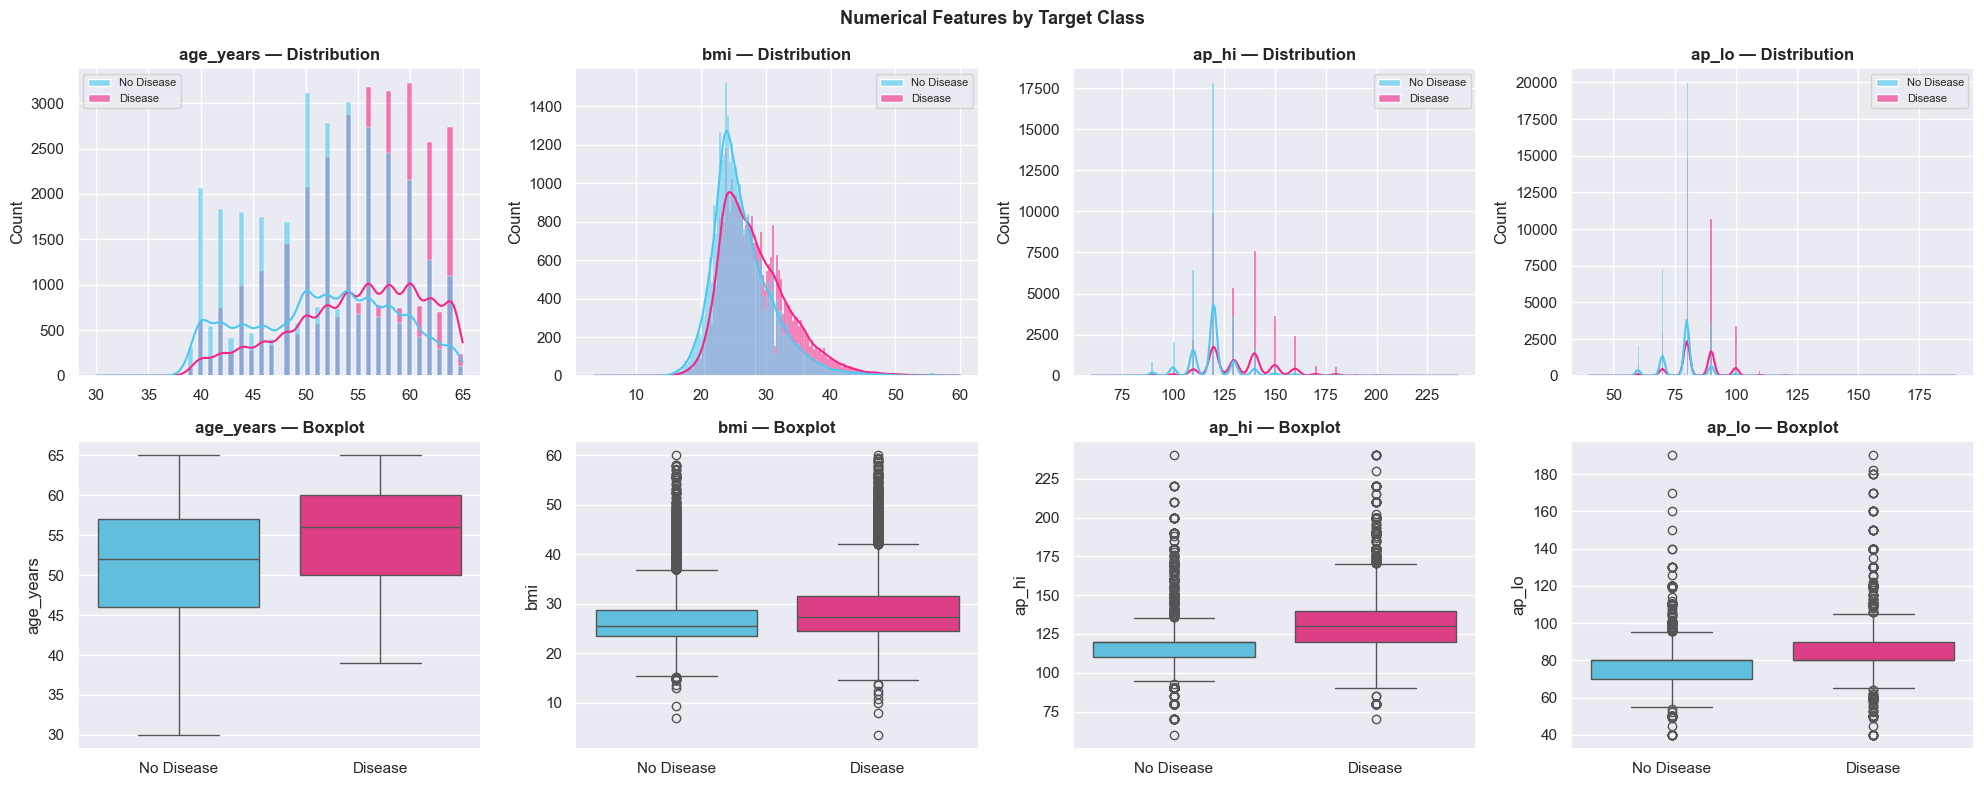

In [10]:
## Again, we will use df_clean for visualization to avoid outliers skewing the plots, but the original df will be used for modeling and analysis.

# ------- Numerical Features Analysis -------

# Numerical features selected for analysis
num_features = ['age_years', 'bmi', 'ap_hi', 'ap_lo']

# Create a 2x4 grid for distribution and boxplot views
fig, axes = plt.subplots(2, 4, figsize=(20, 8))


# ------- Row 1 : Distribution -------

# Plot feature distributions with class-wise separation
for i, feat in enumerate(num_features):
    sns.histplot(
        data=df_clean,
        x=feat,
        hue='cardio',               # split by target class
        hue_order=[0, 1],
        palette={0: '#4cc9f0', 1: '#f72585'},
        kde=True,                   # add density curve
        alpha=0.6,
        ax=axes[0][i]
    )

    axes[0][i].set_title(f'{feat} — Distribution', fontweight='bold')
    axes[0][i].set_xlabel('')

    # Improve legend readability
    axes[0][i].legend(
        handles=axes[0][i].legend_.legend_handles,
        labels=['No Disease', 'Disease'],
        fontsize=8
    )


# ------- Row 2 : Boxplots -------

# Visualize spread and outliers across classes
for i, feat in enumerate(num_features):
    sns.boxplot(
        data=df_clean,
        x='cardio',
        y=feat,
        hue='cardio',               # color by class
        palette={0: '#4cc9f0', 1: '#f72585'},
        legend=False,
        ax=axes[1][i]
    )

    axes[1][i].set_title(f'{feat} — Boxplot', fontweight='bold')
    axes[1][i].set_xlabel('')

    # Replace numeric labels with readable class names
    axes[1][i].set_xticks([0, 1])
    axes[1][i].set_xticklabels(['No Disease', 'Disease'])


# Final layout adjustments
plt.suptitle('Numerical Features by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Overall Summary of Numerical Feature Analysis (After outlier Removal)

### Numerical Features — Summary (After Outlier Removal)

| Feature | Observation | Action | Predictor Strength |
|:---|:---|:---|:---|
| `age_years` | Disease group clearly older (55–60 range) — strong class separation visible | No preprocessing required |  Strong |
| `bmi` | Disease group slightly higher BMI — both classes peak around 25 with noticeable overlap | Can be used as-is or scaled |  Moderate |
| `ap_hi` | Disease group shows higher systolic BP — visible shift toward higher values | Important feature for modeling |  Strong |
| `ap_lo` | Disease group shows slightly higher diastolic BP — moderate separation | Useful feature for modeling |  Moderate |
---
>  `ap_hi` and `ap_lo` show the strongest separation between classes, making them highly valuable for predictive modeling.

---
## 7. Categorical Feature Analysis <a id="7"> </a>

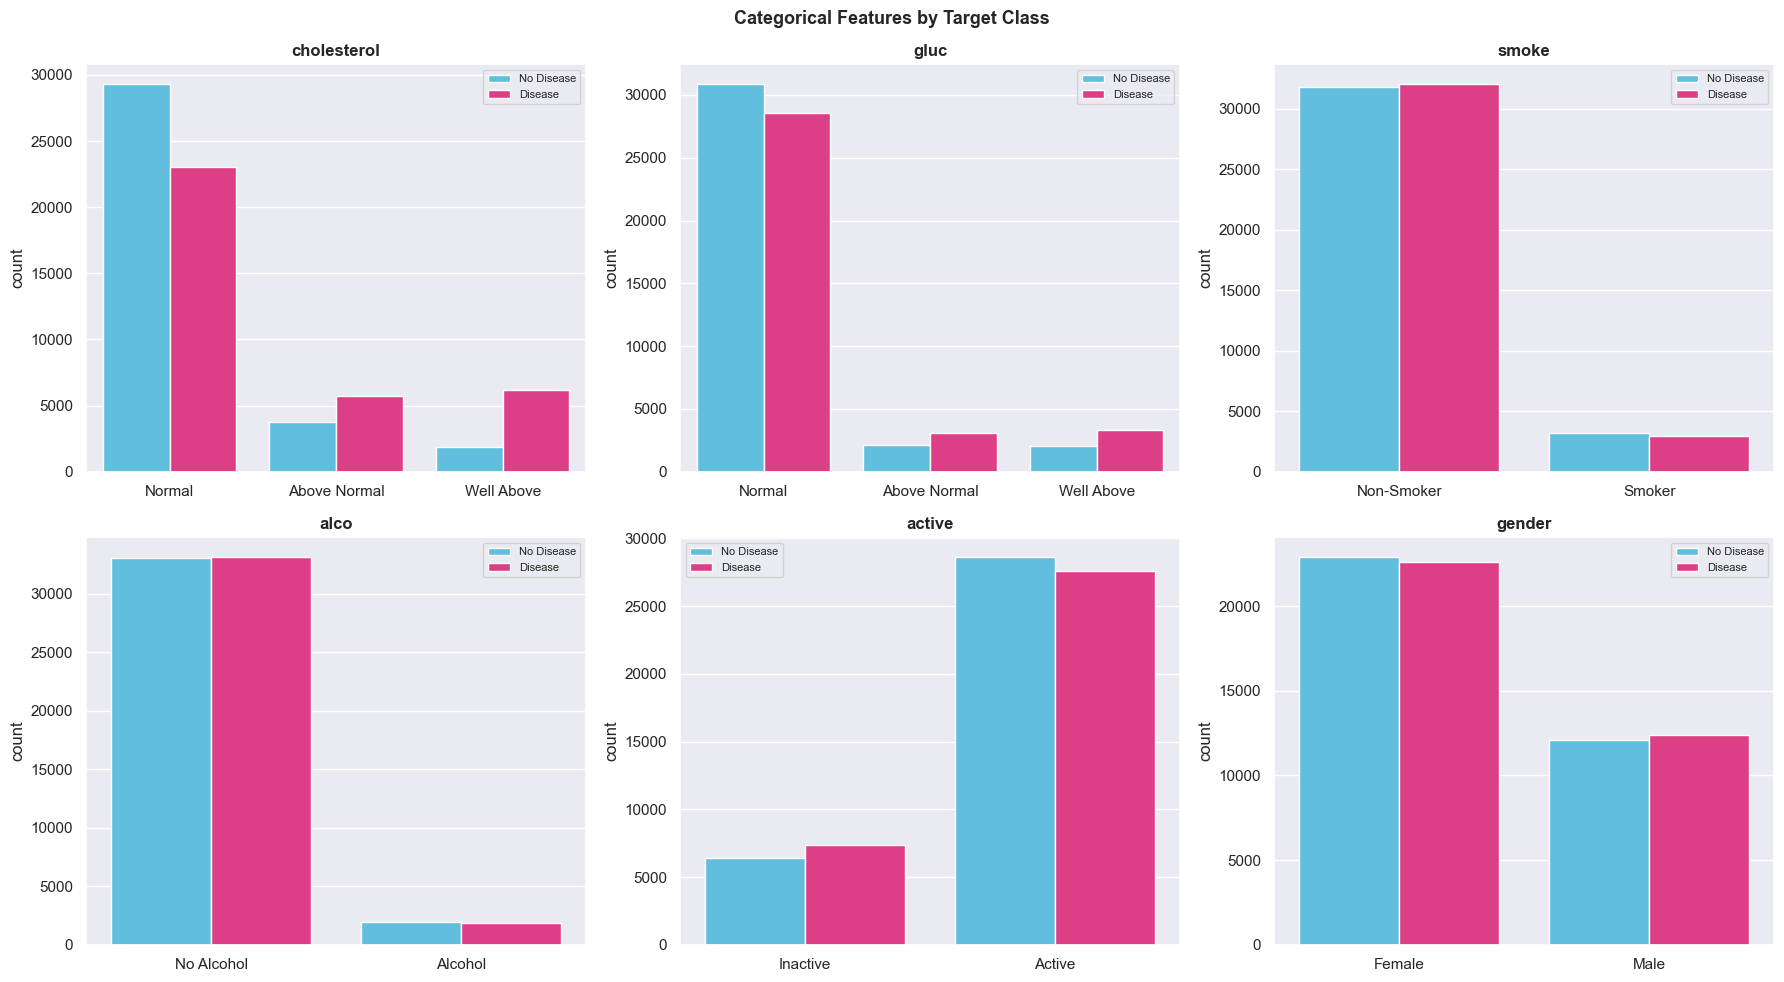

In [11]:
# ------- Categorical Features Analysis -------

# List of categorical features to analyze
cat_features = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']

# Human-readable labels for better interpretability
cat_labels = {
    'cholesterol' : ['Normal', 'Above Normal', 'Well Above'],
    'gluc'        : ['Normal', 'Above Normal', 'Well Above'],
    'smoke'       : ['Non-Smoker', 'Smoker'],
    'alco'        : ['No Alcohol', 'Alcohol'],
    'active'      : ['Inactive', 'Active'],
    'gender'      : ['Female', 'Male']
}

# Create a 2x3 grid layout for visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# ------- Plot each categorical feature vs target -------

# Generate count plots to compare class distribution across categories
for i, feat in enumerate(cat_features):
    sns.countplot(
        data=df,
        x=feat,
        hue='cardio',                 # split by target class
        palette={0: '#4cc9f0', 1: '#f72585'},
        legend=True,
        ax=axes[i]
    )

    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_xlabel('')

    # Replace numeric categories with readable labels
    axes[i].set_xticks(range(len(cat_labels[feat])))
    axes[i].set_xticklabels(cat_labels[feat])

    # Standardize legend labels
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)


# ------- Final layout adjustments -------

plt.suptitle('Categorical Features by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Summary

| Feature | Observation | Predictor Strength |
|:---|:---|:---|
| `cholesterol` | Disease rate clearly increases with cholesterol level — higher categories show a strong shift toward Disease |  Strong |
| `gluc` | Similar pattern to cholesterol but slightly weaker — higher glucose levels show increased disease presence |  Moderate |
| `smoke` | Raw counts suggest higher disease in non-smokers, but this is likely due to category distribution — no clear separable pattern |  Weak |
| `alco` | Similar to smoking — non-smokers show higher counts, but no clear pattern indicating predictive power |  Weak |
| `active` | Inactive individuals show slightly higher disease presence — indicates a mild protective effect of activity |  Moderate |
| `gender` | Male and Female groups show very similar distributions — minimal predictive value |  Weak |
---
>  `cholesterol` is the strongest categorical predictor.  
>  `smoke` and `alco` show misleading patterns in raw counts and require normalized analysis.  
> ➖ `gender` has minimal impact, while `active` provides a moderate signal.

---
## 8. Correlation Analysis <a id='9'></a>

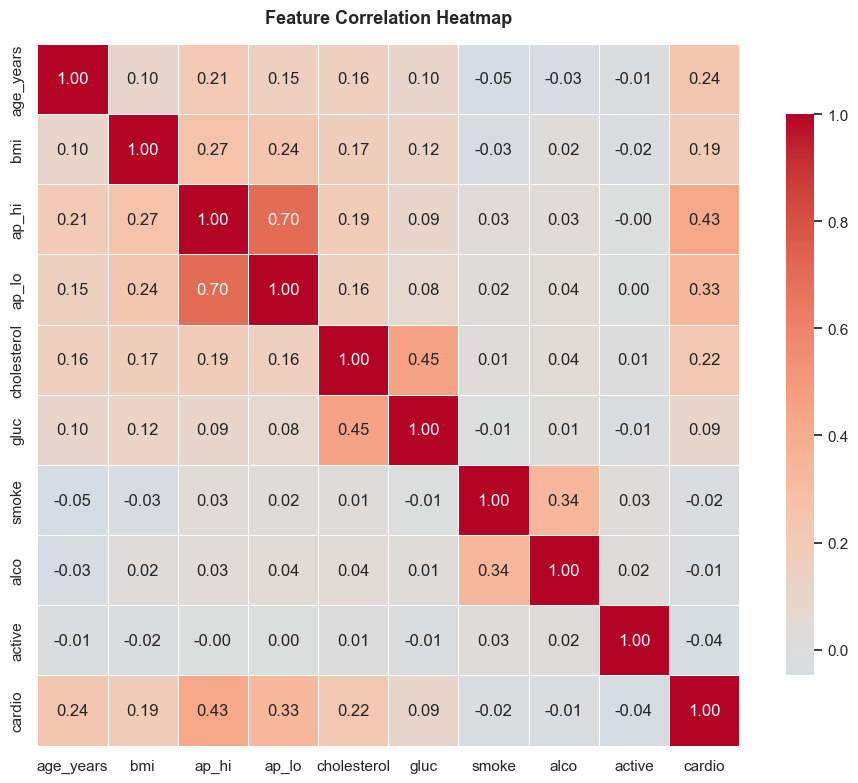

Feature Correlation with Target (cardio):
ap_hi          0.43
ap_lo          0.33
age_years      0.24
cholesterol    0.22
bmi            0.19
gluc           0.09
alco          -0.01
smoke         -0.02
active        -0.04


In [12]:
# ------- Correlation Analysis -------

# Select relevant features for correlation (exclude non-informative columns like 'id')
corr_cols = ['age_years', 'bmi', 'ap_hi', 'ap_lo',
             'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

# Compute pairwise correlation matrix
corr_matrix = df_clean[corr_cols].corr()


# ------- Heatmap Visualization -------

plt.figure(figsize=(10, 8))

# Visualize correlations using heatmap
sns.heatmap(
    corr_matrix,
    annot=True,                  # display correlation coefficients
    fmt='.2f',                   # format values to 2 decimal places
    cmap='coolwarm',             # color scale: red (positive), blue (negative)
    center=0,                    # center color scale at zero
    square=True,                 # maintain square cells
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}     # adjust colorbar size
)

plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# ------- Correlation with Target -------

# Extract correlation of each feature with target variable
target_corr = corr_matrix['cardio'].drop('cardio').sort_values(ascending=False)

# Print sorted correlations for quick interpretation
print("Feature Correlation with Target (cardio):")
print(target_corr.to_string())

---
## 9. Key Insights & Next Steps <a id='10'></a>

| # | Finding |
|---|---|
| 1 | Dataset is **well-balanced** — ~50/50 split, no SMOTE needed |
| 2 | **Systolic BP (ap_hi)** has the highest correlation with disease |
| 3 | **Age** is a strong predictor — older patients more at risk |
| 4 | **High cholesterol** significantly increases disease risk |
| 5 | **Lifestyle factors** (smoke, alco) show weaker individual effect |
| 6 | BP features contain **outliers** that must be removed |

  Next Steps

-  Convert `age` from days to years
-  Calculate `bmi` from height and weight
-  Create `pulse_pressure` = ap_hi - ap_lo
-  Create `bp_category` (normal, elevated, hypertension)
-  Encode categorical features
-  Scale numerical features

---
*End of EDA Notebook*